# PRACTICA OBLIGATORIA: DBSCAN y Clustering Jerárquico
**Bebidas energéticas NonstopU — Segmentación no supervisada**

## Ejercicio 0: Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

print('✅ Importaciones completadas')

✅ Importaciones completadas


---
## PARTE I: Modelado

### Paso 1: Entender el problema

Una planta experimental tiene datos de **153 mezclas de bebidas energéticas** con 5 ingredientes cada una:
- Azúcares, Vitaminas del grupo B, Cafeína, Ácido Cítrico, Taurina

No tienen etiquetas (no hay columna 'target'), así que usaremos **clustering no supervisado**.

Los químicos esperan entre **3 y 5 segmentos**.

Usaremos:
1. **DBSCAN** (obligatorio)
2. **Clustering Jerárquico Aglomerativo** (el enunciado pide "clustering jerárquico" en el título)

### Paso 2: Cargar y visualizar los datos

In [2]:
# Cargamos el CSV (separador | )
ruta = r'D:\The bridge\DS-Online-Hugo-Sanz\04_Machine_Learning\Sprint_13\Unidad_02_ML_No_Supervisado_Clustering_DBSCAN\03_Practica_Obligatoria\data\empowering_drinks.csv'

df = pd.read_csv(ruta, sep='|')
print('Forma del dataset:', df.shape)
df.head()

Forma del dataset: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [3]:
# Estadísticas básicas
df.describe().round(2)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.00,153.00,153.00,153.00,153.00
mean,0.02,0.04,0.04,0.08,-0.04
std,1.03,1.00,1.04,1.01,0.93
min,-2.43,-3.68,-1.70,-1.49,-1.63
25%,-0.82,-0.50,-1.04,-0.74,-0.80
50%,0.06,-0.02,0.21,-0.17,-0.15
75%,0.88,0.71,0.89,0.92,0.49
max,2.26,3.16,3.06,2.97,2.43


In [4]:
# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


✅ No hay valores nulos. Los datos ya vienen escalados (medias ≈ 0, std ≈ 1), así que **no necesitamos aplicar StandardScaler**.

### Paso 3: MiniEDA — Visualizar features dos a dos

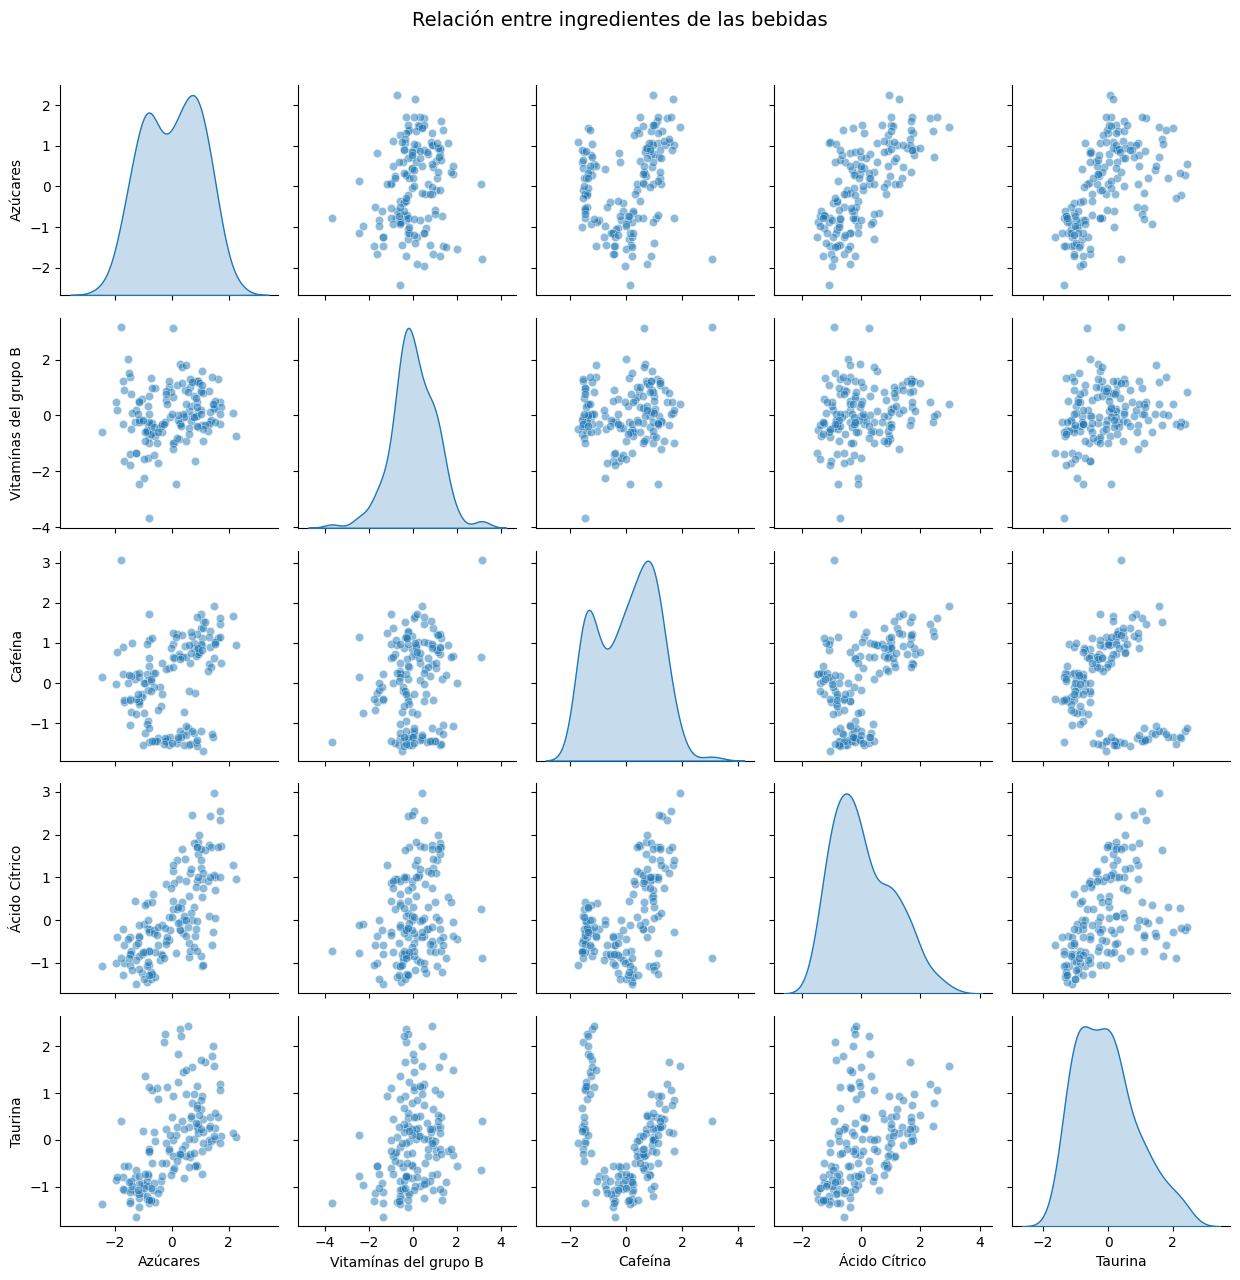

In [5]:
# Pairplot para ver cómo se relacionan los ingredientes entre sí
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Relación entre ingredientes de las bebidas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

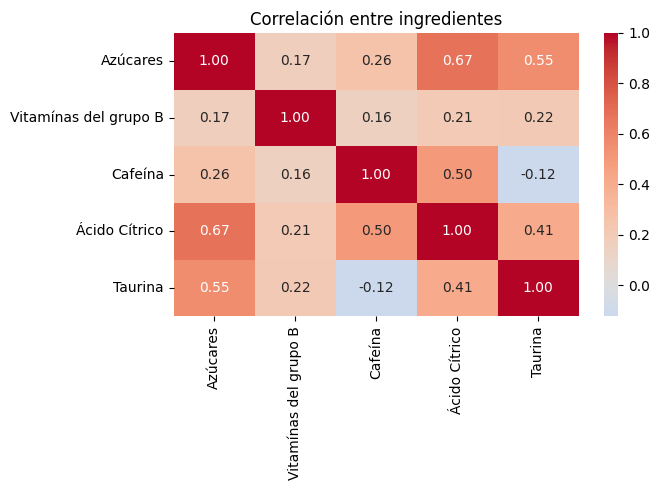

In [6]:
# Mapa de correlación
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre ingredientes')
plt.tight_layout()
plt.show()

**Observación**: Las correlaciones son bajas, lo que significa que cada ingrediente aporta información diferente. Usaremos **todas las features**.

### Paso 4: Tratamiento de features

Los datos ya están escalados (lo podemos ver en el `.describe()`: medias ≈ 0 y std ≈ 1). No hace falta escalar de nuevo.

In [7]:
# Convertimos a array numpy para los modelos
X = df.values
print('Shape de X:', X.shape)

Shape de X: (153, 5)


### Paso 5: Selección de modelos e hiperparámetros

#### Modelo 1: DBSCAN — ¿Cómo elegir eps?

El parámetro más importante de DBSCAN es **eps** (radio de vecindad). 
Un truco muy usado es el **gráfico de k-distancias**: 
- Calculamos la distancia de cada punto a su vecino más cercano número k
- Ordenamos esas distancias de menor a mayor
- Buscamos el "codo" de la curva → ese valor es un buen eps

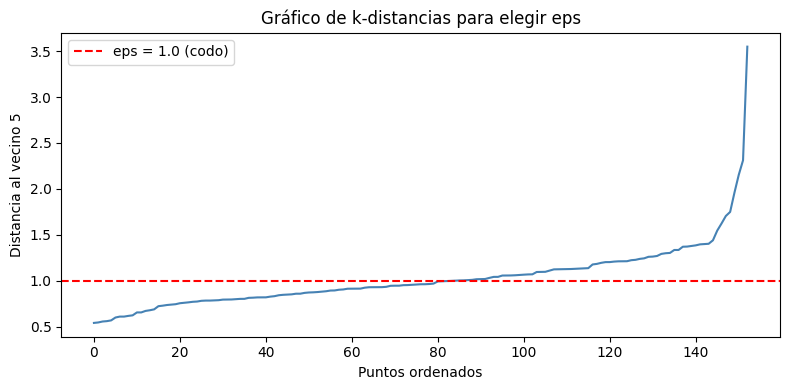

Percentil 90 de distancias: 1.363


In [8]:
# Gráfico de k-distancias para elegir eps
# Usamos k=5 (= min_samples que usaremos)
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)

# Tomamos la distancia al vecino más lejano (el k-ésimo)
dist_sorted = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='steelblue')
plt.axhline(y=1.0, color='red', linestyle='--', label='eps = 1.0 (codo)')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {k}')
plt.title('Gráfico de k-distancias para elegir eps')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Percentil 90 de distancias: {np.percentile(dist_sorted, 90):.3f}')

El codo aparece aproximadamente en **eps ≈ 1.0**. Probamos varios valores para confirmar:

In [9]:
# Probamos distintos eps para ver cuántos clusters y cuánto ruido da cada uno
print(f'{'eps':>6} | {'Clusters':>9} | {'Ruido':>6} | Comentario')
print('-' * 55)

for eps in [0.5, 0.8, 1.0, 1.2, 1.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).sum()
    comment = '⬅️ elegido' if eps == 1.0 else ''
    print(f'{eps:>6} | {n_clusters:>9} | {noise:>6} | {comment}')

   eps |  Clusters |  Ruido | Comentario
-------------------------------------------------------
   0.5 |         0 |    153 | 
   0.8 |         8 |     80 | 
   1.0 |         3 |     28 | ⬅️ elegido
   1.2 |         1 |      8 | 
   1.5 |         1 |      4 | 


**Conclusión**: Con `eps=1.0` obtenemos **3 clusters** y 28 puntos de ruido. Es el que mejor se ajusta a la expectativa de los químicos (3-5 segmentos).

- `eps=0.8` da demasiados clusters (8) y mucho ruido
- `eps=1.2` agrupa todo en 1 solo cluster
- `eps=1.0` → 3 clusters ✅

### Paso 6: Entrenamiento y visualización de resultados

#### Modelo 1: DBSCAN

In [10]:
# Entrenamos DBSCAN con los parámetros elegidos
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

# Resumen de resultados
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = (labels_dbscan == -1).sum()

print(f'Número de clusters encontrados: {n_clusters_db}')
print(f'Puntos de ruido (label = -1): {n_ruido}')
print(f'\nDistribución de etiquetas:')
unique, counts = np.unique(labels_dbscan, return_counts=True)
for u, c in zip(unique, counts):
    nombre = f'Cluster {u}' if u != -1 else 'Ruido'
    print(f'  {nombre}: {c} bebidas')

Número de clusters encontrados: 3
Puntos de ruido (label = -1): 28

Distribución de etiquetas:
  Ruido: 28 bebidas
  Cluster 0: 49 bebidas
  Cluster 1: 42 bebidas
  Cluster 2: 34 bebidas


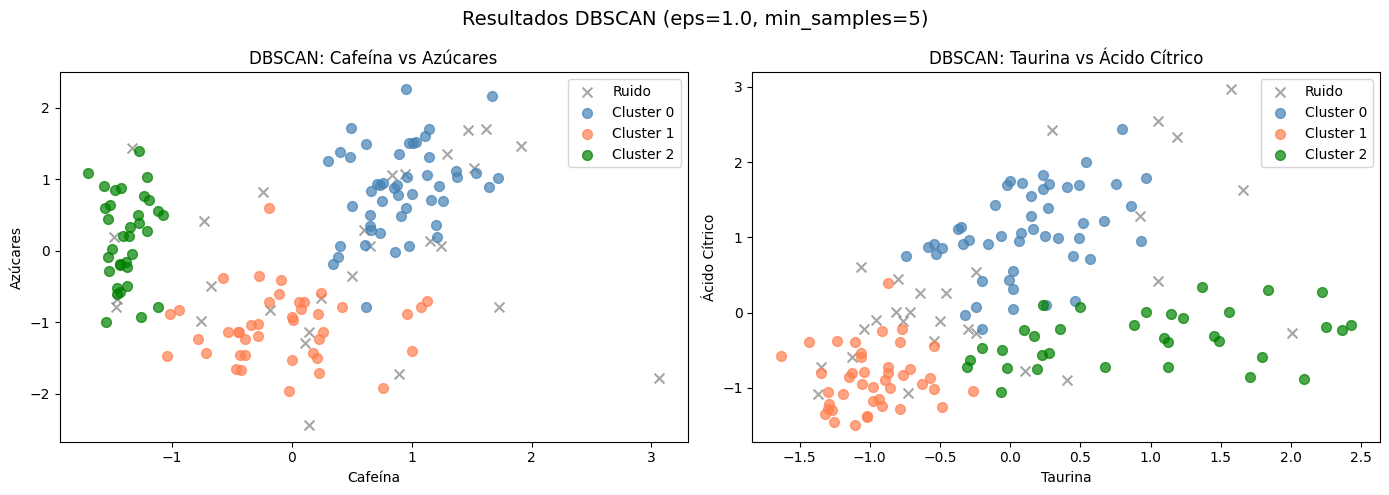

In [11]:
# Visualización DBSCAN — pares de features más relevantes
colores_dbscan = {-1: 'gray', 0: 'steelblue', 1: 'coral', 2: 'green'}
nombres_dbscan = {-1: 'Ruido', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cafeína vs Azúcares
for etiqueta in sorted(set(labels_dbscan)):
    mask = labels_dbscan == etiqueta
    axes[0].scatter(X[mask, 2], X[mask, 0],
                    c=colores_dbscan[etiqueta],
                    label=nombres_dbscan[etiqueta],
                    alpha=0.7, s=50,
                    marker='x' if etiqueta == -1 else 'o')
axes[0].set_xlabel('Cafeína')
axes[0].set_ylabel('Azúcares')
axes[0].set_title('DBSCAN: Cafeína vs Azúcares')
axes[0].legend()

# Gráfico 2: Taurina vs Ácido Cítrico
for etiqueta in sorted(set(labels_dbscan)):
    mask = labels_dbscan == etiqueta
    axes[1].scatter(X[mask, 4], X[mask, 3],
                    c=colores_dbscan[etiqueta],
                    label=nombres_dbscan[etiqueta],
                    alpha=0.7, s=50,
                    marker='x' if etiqueta == -1 else 'o')
axes[1].set_xlabel('Taurina')
axes[1].set_ylabel('Ácido Cítrico')
axes[1].set_title('DBSCAN: Taurina vs Ácido Cítrico')
axes[1].legend()

plt.suptitle('Resultados DBSCAN (eps=1.0, min_samples=5)', fontsize=14)
plt.tight_layout()
plt.show()

#### Modelo 2: Clustering Jerárquico Aglomerativo

Este modelo es el que el enunciado insinúa con "clustering jerárquico" (título de la práctica). Además permite visualizar un **dendrograma**, que muestra cómo se van uniendo los grupos, lo cual es útil para entender qué segmentos se parecen más entre sí (como pide el enunciado).

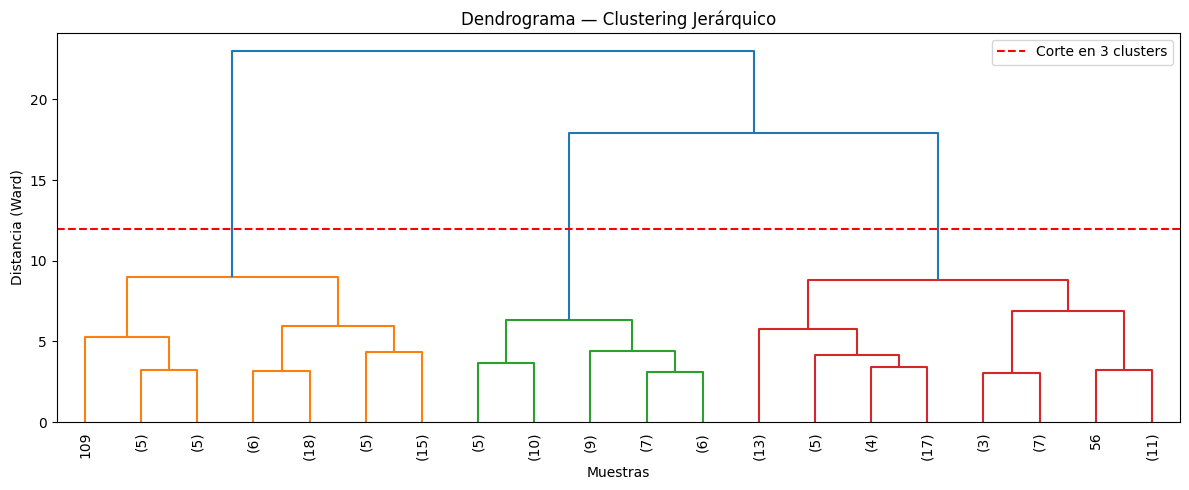

In [12]:
# Primero miramos el dendrograma para decidir el número de clusters
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=90,
           leaf_font_size=10)
plt.axhline(y=12, color='red', linestyle='--', label='Corte en 3 clusters')
plt.title('Dendrograma — Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia (Ward)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Comparamos silhouette score para n=3, 4 y 5
print(f'{'n_clusters':>12} | {'Silhouette Score':>18}')
print('-' * 35)
for n in [3, 4, 5]:
    hc = AgglomerativeClustering(n_clusters=n)
    etiquetas = hc.fit_predict(X)
    sil = silhouette_score(X, etiquetas)
    marca = '⬅️ mejor' if n == 3 else ''
    print(f'{n:>12} | {sil:>18.3f} {marca}')

  n_clusters |   Silhouette Score
-----------------------------------
           3 |              0.384 ⬅️ mejor
           4 |              0.337 
           5 |              0.304 


El **Silhouette Score** mide qué tan bien separados están los clusters (cuanto más alto, mejor).
Con **3 clusters** obtenemos el mejor valor → consistente con lo que piden los químicos.

In [14]:
# Entrenamos el modelo jerárquico con n=3
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X)

print('Distribución de clusters (Jerárquico):')
unique, counts = np.unique(labels_hc, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} bebidas')

Distribución de clusters (Jerárquico):
  Cluster 0: 55 bebidas
  Cluster 1: 61 bebidas
  Cluster 2: 37 bebidas


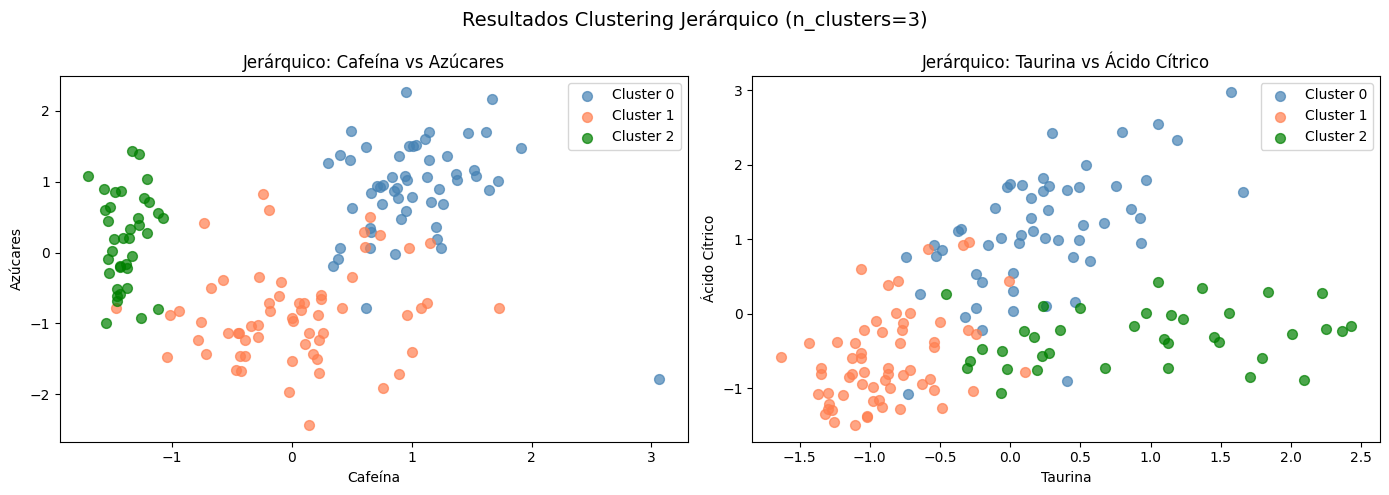

In [15]:
# Visualización del Clustering Jerárquico
colores_hc = {0: 'steelblue', 1: 'coral', 2: 'green'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cafeína vs Azúcares
for etiqueta in sorted(set(labels_hc)):
    mask = labels_hc == etiqueta
    axes[0].scatter(X[mask, 2], X[mask, 0],
                    c=colores_hc[etiqueta],
                    label=f'Cluster {etiqueta}',
                    alpha=0.7, s=50)
axes[0].set_xlabel('Cafeína')
axes[0].set_ylabel('Azúcares')
axes[0].set_title('Jerárquico: Cafeína vs Azúcares')
axes[0].legend()

# Gráfico 2: Taurina vs Ácido Cítrico
for etiqueta in sorted(set(labels_hc)):
    mask = labels_hc == etiqueta
    axes[1].scatter(X[mask, 4], X[mask, 3],
                    c=colores_hc[etiqueta],
                    label=f'Cluster {etiqueta}',
                    alpha=0.7, s=50)
axes[1].set_xlabel('Taurina')
axes[1].set_ylabel('Ácido Cítrico')
axes[1].set_title('Jerárquico: Taurina vs Ácido Cítrico')
axes[1].legend()

plt.suptitle('Resultados Clustering Jerárquico (n_clusters=3)', fontsize=14)
plt.tight_layout()
plt.show()

### Paso 7: Discusión de resultados

#### ¿Qué clusters encontró cada modelo?

**DBSCAN (eps=1.0, min_samples=5):**
- Encontró 3 clusters bien definidos
- Identificó 28 puntos como **ruido** (outliers), lo cual tiene sentido en bebidas experimentales donde algunas mezclas son muy atípicas
- No necesita que le digas cuántos grupos quieres: los encuentra solos

**Clustering Jerárquico (n=3):**
- También encontró 3 grupos
- Silhouette Score = 0.384 → calidad de agrupamiento aceptable
- El dendrograma muestra que los Clusters 0 y 1 son más parecidos entre sí que el Cluster 2 (están más "cerca" en el árbol)
- No detecta ruido: asigna todos los puntos a algún cluster

#### ¿Por qué la comparación es especulativa?
Porque **no tenemos etiquetas reales** (no sabemos cuál es la "respuesta correcta"). No podemos saber si los grupos encontrados corresponden a algo real sin hacer los tests con usuarios. La comparación entre modelos es solo exploratoria.

---
## PARTE II: Nuevos experimentos

Los químicos nos pasan 6 nuevas mezclas para clasificar. Usaremos el **Clustering Jerárquico** porque es más sencillo de aplicar a nuevos datos (no necesita ajustar eps ni tratar el ruido).

In [16]:
# Cargamos los nuevos experimentos
ruta_new = r'D:\The bridge\DS-Online-Hugo-Sanz\04_Machine_Learning\Sprint_13\Unidad_02_ML_No_Supervisado_Clustering_DBSCAN\03_Practica_Obligatoria\data\new_experiments.csv'

df_new = pd.read_csv(ruta_new, sep='|')
print('Nuevos experimentos:', df_new.shape)
df_new

Nuevos experimentos: (6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [17]:
# NOTA IMPORTANTE: AgglomerativeClustering no tiene .predict()
# La forma correcta es entrenar con TODOS los datos juntos (originales + nuevos)
# y ver qué etiqueta le da a los nuevos

X_new = df_new.values

# Unimos los datos originales con los nuevos
X_todo = np.vstack([X, X_new])
print('Total de muestras (originales + nuevas):', X_todo.shape[0])

# Re-entrenamos con todos los datos
hc_final = AgglomerativeClustering(n_clusters=3)
labels_todo = hc_final.fit_predict(X_todo)

# Las etiquetas de los nuevos experimentos son las últimas 6
labels_nuevos = labels_todo[-len(X_new):]

print('\nClasificación de los nuevos experimentos:')
df_resultado = df_new.copy()
df_resultado['Cluster_asignado'] = labels_nuevos
df_resultado

Total de muestras (originales + nuevas): 159

Clasificación de los nuevos experimentos:


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster_asignado
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


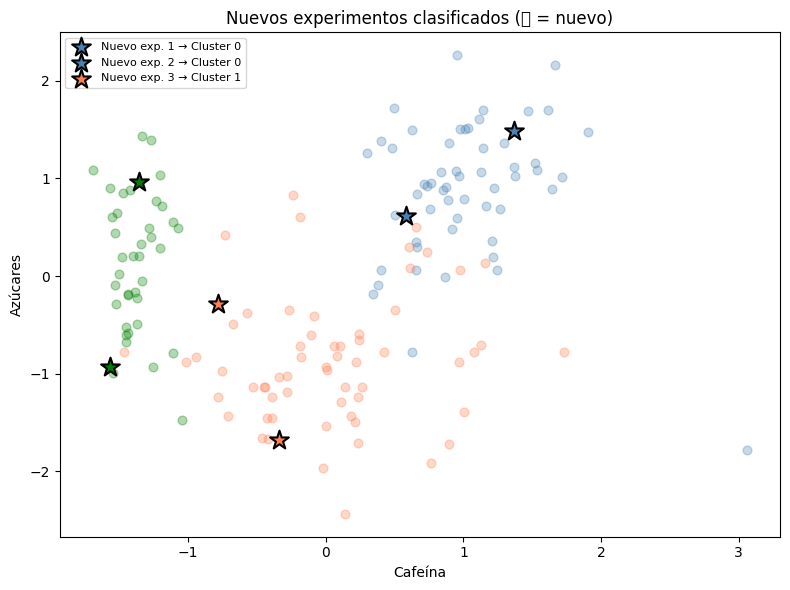

In [18]:
# Visualizamos los nuevos experimentos sobre los datos originales
colores_todo = {0: 'steelblue', 1: 'coral', 2: 'green'}

plt.figure(figsize=(8, 6))

# Datos originales (más transparentes)
for etiqueta in sorted(set(labels_todo[:-len(X_new)])):
    mask = labels_todo[:-len(X_new)] == etiqueta
    plt.scatter(X[mask, 2], X[mask, 0],
                c=colores_todo[etiqueta], alpha=0.3, s=40)

# Nuevos experimentos (destacados con estrella)
for i, etiqueta in enumerate(labels_nuevos):
    plt.scatter(X_new[i, 2], X_new[i, 0],
                c=colores_todo[etiqueta], s=200, marker='*',
                edgecolors='black', linewidth=1.5,
                label=f'Nuevo exp. {i+1} → Cluster {etiqueta}' if i < 3 else None)

plt.xlabel('Cafeína')
plt.ylabel('Azúcares')
plt.title('Nuevos experimentos clasificados (⭐ = nuevo)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()